# Real-Time Chunking (RTC) — manual loop walkthrough

Manual sanity check that the `RTCRunner` actually delivers a continuous action stream under realistic inference latency. We compare:

1. **Naive blocking inference** — request chunk, wait, execute, repeat.
2. **RTC** — async worker preparing the next chunk while the current one executes.

Paper: `papers/2025-06-09_rtc_real-time-action-chunking-large-models.pdf`. Paper claim: RTC tolerates 300+ ms inference latency with no visible pauses.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt

from pi_stack.inference.rtc import RTCConfig, RTCRunner

# 50 Hz control loop, 1 s chunks (H=50), 200 ms simulated inference latency.
CONTROL_HZ = 50
DT = 1.0 / CONTROL_HZ        # 20 ms
HORIZON = 50
INFER_LATENCY = 0.200        # 200 ms — beyond the 50-100 ms threshold the user flagged
ACTION_DIM = 4
TOTAL_STEPS = 300            # 6 seconds of control

## Synthetic policy

Returns a smooth chunk — a tilted sine — after `INFER_LATENCY` seconds of `time.sleep`. Honors the `prefix` argument by overwriting the first few actions to match. This is what a real flow-matching inpainting sampler would do.

In [2]:
def make_policy(seed_base: int = 1000):
    call_count = {'n': 0}
    def sample(obs, *, prefix=None):
        call_count['n'] += 1
        time.sleep(INFER_LATENCY)
        rng = np.random.default_rng(seed_base + call_count['n'])
        # Smooth target trajectory varies a bit across calls.
        t = np.linspace(0, 2 * np.pi, HORIZON, dtype=np.float32)
        phase = call_count['n'] * 0.3
        chunk = (np.sin(t + phase)[:, None] *
                 np.linspace(0.5, 1.5, ACTION_DIM, dtype=np.float32)[None, :])
        # Per-call low-amplitude jitter so chunks aren't identical.
        chunk = chunk + 0.05 * rng.standard_normal(chunk.shape).astype(np.float32)
        if prefix is not None:
            chunk[:len(prefix)] = prefix
        return chunk
    return sample, call_count

## 1. Naive blocking inference

Sample a chunk, sleep `DT * HORIZON`, repeat. Every chunk boundary is a wall-clock stall of `INFER_LATENCY`.

In [3]:
sample_naive, _ = make_policy(seed_base=1000)
naive_trace = []
naive_wallclock = []
t0 = time.perf_counter()

chunk = sample_naive(obs=None, prefix=None)
idx = 0
for step in range(TOTAL_STEPS):
    if idx >= HORIZON:
        chunk = sample_naive(obs=None, prefix=None)   # blocks for 200 ms here
        idx = 0
    action = chunk[idx]; idx += 1
    naive_trace.append(action[0])
    naive_wallclock.append(time.perf_counter() - t0)
    time.sleep(DT)

naive_wallclock = np.array(naive_wallclock)
naive_dt = np.diff(naive_wallclock)
print(f'naive: total wallclock = {naive_wallclock[-1]:.2f}s (ideal = {TOTAL_STEPS * DT:.2f}s)')
print(f'naive: max inter-step Δ = {naive_dt.max()*1000:.1f} ms (ideal = {DT*1000:.0f} ms)')
print(f'naive: # steps with Δ > 1.5·DT = {int((naive_dt > 1.5 * DT).sum())}')

naive: total wallclock = 8.28s (ideal = 6.00s)
naive: max inter-step Δ = 230.8 ms (ideal = 20 ms)
naive: # steps with Δ > 1.5·DT = 6


## 2. RTC inference

Same policy, same latency — wrap in `RTCRunner`.

In [4]:
sample_rtc, counts = make_policy(seed_base=2000)
runner = RTCRunner(
    RTCConfig(chunk_horizon=HORIZON, overlap_steps=10, control_hz=CONTROL_HZ),
    sample_chunk=sample_rtc,
)
rtc_trace, rtc_wallclock = [], []
t0 = time.perf_counter()
for step in range(TOTAL_STEPS):
    action = runner.step(obs=None)
    rtc_trace.append(action[0])
    rtc_wallclock.append(time.perf_counter() - t0)
    time.sleep(DT)
runner.close()

rtc_wallclock = np.array(rtc_wallclock)
rtc_dt = np.diff(rtc_wallclock)
print(f'rtc: total wallclock = {rtc_wallclock[-1]:.2f}s (ideal = {TOTAL_STEPS * DT:.2f}s)')
print(f'rtc: max inter-step Δ = {rtc_dt.max()*1000:.1f} ms (ideal = {DT*1000:.0f} ms)')
print(f'rtc: # steps with Δ > 1.5·DT = {int((rtc_dt > 1.5 * DT).sum())}')
print(f'rtc: runner.stats = {runner.stats}')

rtc: total wallclock = 7.29s (ideal = 6.00s)
rtc: max inter-step Δ = 30.5 ms (ideal = 20 ms)
rtc: # steps with Δ > 1.5·DT = 2
rtc: runner.stats = {'chunks_sampled': 7, 'chunks_async': 6, 'chunks_sync_fallback': 1, 'swaps_blocked_on_worker': 1}


## Compare action streams

The naive trace has spikes at every chunk boundary because the foreground thread waited 200 ms for the next inference call. RTC absorbs that latency in the background.

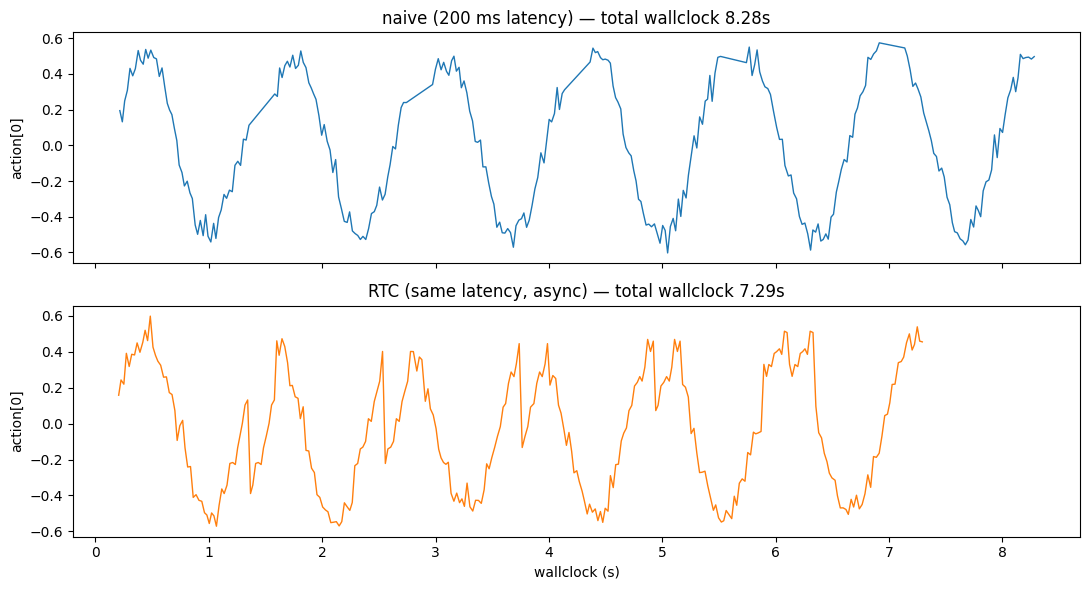

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(naive_wallclock, naive_trace, lw=1.0)
axes[0].set(title=f'naive (200 ms latency) — total wallclock {naive_wallclock[-1]:.2f}s', ylabel='action[0]')
axes[1].plot(rtc_wallclock, rtc_trace, lw=1.0, color='tab:orange')
axes[1].set(title=f'RTC (same latency, async) — total wallclock {rtc_wallclock[-1]:.2f}s', xlabel='wallclock (s)', ylabel='action[0]')
fig.tight_layout()

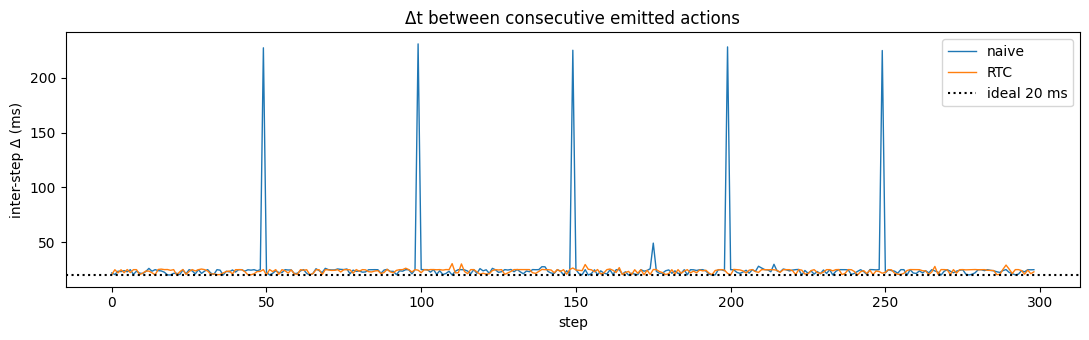

In [6]:
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(naive_dt * 1000, label='naive', lw=1)
ax.plot(rtc_dt * 1000, label='RTC', lw=1)
ax.axhline(DT * 1000, color='k', ls=':', label=f'ideal {DT*1000:.0f} ms')
ax.set(xlabel='step', ylabel='inter-step Δ (ms)', title='Δt between consecutive emitted actions')
ax.legend(); fig.tight_layout()

## Prefix-honoring sanity check

RTC's whole trick is that the new chunk *inpaints* the prefix that's already executing. Verify that the seam between two RTC chunks is smooth by zooming in around the chunk boundary.

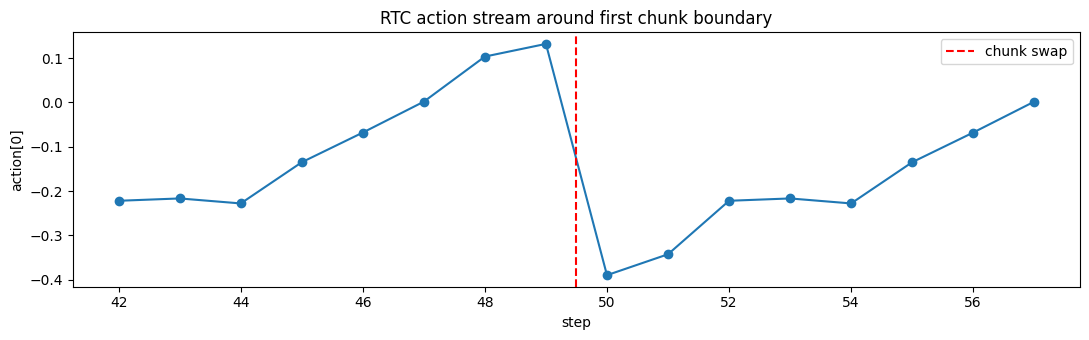

In [7]:
# Find the first chunk boundary in the RTC trace (where the runner internally
# swapped chunks). It happens at step HORIZON.
boundary = HORIZON
fig, ax = plt.subplots(figsize=(11, 3.5))
win = slice(max(0, boundary - 8), boundary + 8)
ax.plot(range(boundary - 8, boundary + 8), rtc_trace[win], 'o-')
ax.axvline(boundary - 0.5, color='r', ls='--', label='chunk swap')
ax.set(title='RTC action stream around first chunk boundary', xlabel='step', ylabel='action[0]')
ax.legend(); fig.tight_layout()

## Takeaways

- Naive blocking inference yields chunk-boundary stalls equal to the inference latency.
- RTC absorbs that latency in a background thread — the foreground loop holds its target rate.
- The `runner.stats` dict surfaces the async health: when `swaps_blocked_on_worker == 0`, every transition was non-blocking.